# QAE training


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# print(PROJECT_ROOT)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import pandas as pd


import seaborn as sns
import matplotlib.pyplot as plt
import pennylane as qml

from qae import QAEConfig, QuantumAutoencoder
from preprocessing import timed_preprocess

In [1]:
VERBOSE = False

In [3]:
prep = timed_preprocess(percent10=True, n_components=4, vis_samples=1000)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

KDD99 preprocessing time: 18.27s
Full train: (155644, 4)
Full test:  (98805, 4)


In [ ]:
X_train_qae_full, X_val_qae, y_train_qae_full, y_val_qae = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

rng = np.random.default_rng(42)

train_subset_size = 6000
train_idx = rng.choice(len(X_train_qae_full), size=train_subset_size, replace=False)
X_train_qae = X_train_qae_full[train_idx]
y_train_qae = y_train_qae_full[train_idx]

val_subset_size = 650 
val_idx = rng.choice(len(X_val_qae), size=val_subset_size, replace=False)
X_val_qae_small = X_val_qae[val_idx]
y_val_qae_small = y_val_qae[val_idx]

print("QAE train subset:", X_train_qae.shape)
print("QAE val subset:  ", X_val_qae_small.shape)

QAE train subset: (6000, 4)
QAE val subset:   (650, 4)


In [4]:
config = QAEConfig(
    n_qubits=4,
    n_latent=2,
    n_layers=1,
    device_name="default.qubit",
    seed=42,
    use_swap_test_loss=True,
    use_log_cost=True,
)

qae = QuantumAutoencoder(config)

best_params, history, scaler = qae.train(
    X_train_raw=X_train_qae,
    X_val_raw=X_val_qae_small,
    steps=80,  #80
    lr=0.03,
    batch_size=32, #32
    val_every=10, 
    verbose=True,
)

[Step 000] train_loss=-0.145127 | val_loss=-0.170830
[Step 005] train_loss=-0.191548
[Step 010] train_loss=-0.256753 | val_loss=-0.252012
[Step 015] train_loss=-0.339527
[Step 020] train_loss=-0.308614 | val_loss=-0.338914
[Step 025] train_loss=-0.337096
[Step 030] train_loss=-0.473071 | val_loss=-0.393996
[Step 035] train_loss=-0.338336
[Step 040] train_loss=-0.434190 | val_loss=-0.403027
[Step 045] train_loss=-0.438818
[Step 050] train_loss=-0.274646 | val_loss=-0.405544
[Step 055] train_loss=-0.463420
[Step 060] train_loss=-0.391407 | val_loss=-0.409263
[Step 065] train_loss=-0.470567
[Step 070] train_loss=-0.501121 | val_loss=-0.409729
[Step 075] train_loss=-0.445294
[Step 079] train_loss=-0.400627 | val_loss=-0.410319


In [7]:
qae.save_checkpoint(
    "qae_checkpoint.npz",
    params=best_params,
    scaler=scaler,
    history=history,
    extra_metadata={"dataset": "KDDCup99 PCA-4"}
)

In [8]:
svm_train_size = 10000
svm_test_size = 5000

train_idx_small = rng.choice(len(X_train), size=svm_train_size, replace=False)
test_idx_small = rng.choice(len(X_test), size=svm_test_size, replace=False)

X_train_small = X_train[train_idx_small]
y_train_small = y_train[train_idx_small]

X_test_small = X_test[test_idx_small]
y_test_small = y_test[test_idx_small]

In [2]:
if (VERBOSE):
    x_sample = qae.transform_to_angles(X_train_small[:1], scaler)[0]

    fig, ax = qml.draw_mpl(qae.trash_probs_qnode)(x_sample, best_params)
    ax.set_title("Encoder circuit")
    plt.show()

    fig, ax = qml.draw_mpl(qae.swap_test_prob_qnode)(x_sample, best_params)
    ax.set_title("QAE circuit")
    plt.show()

In [10]:
Z_train = qae.batch_transform_latent_features_from_raw(
    X_train_small,
    best_params,
    scaler,
    batch_size=500,
    verbose=True,
)

Z_test = qae.batch_transform_latent_features_from_raw(
    X_test_small,
    best_params,
    scaler,
    batch_size=500,
    verbose=True,
)

print("Z_train:", Z_train.shape)
print("Z_test: ", Z_test.shape)

Latent transform: 500/10000
Latent transform: 1000/10000
Latent transform: 1500/10000
Latent transform: 2000/10000
Latent transform: 2500/10000
Latent transform: 3000/10000
Latent transform: 3500/10000
Latent transform: 4000/10000
Latent transform: 4500/10000
Latent transform: 5000/10000
Latent transform: 5500/10000
Latent transform: 6000/10000
Latent transform: 6500/10000
Latent transform: 7000/10000
Latent transform: 7500/10000
Latent transform: 8000/10000
Latent transform: 8500/10000
Latent transform: 9000/10000
Latent transform: 9500/10000
Latent transform: 10000/10000
Latent transform: 500/5000
Latent transform: 1000/5000
Latent transform: 1500/5000
Latent transform: 2000/5000
Latent transform: 2500/5000
Latent transform: 3000/5000
Latent transform: 3500/5000
Latent transform: 4000/5000
Latent transform: 4500/5000
Latent transform: 5000/5000
Z_train: (10000, 2)
Z_test:  (5000, 2)


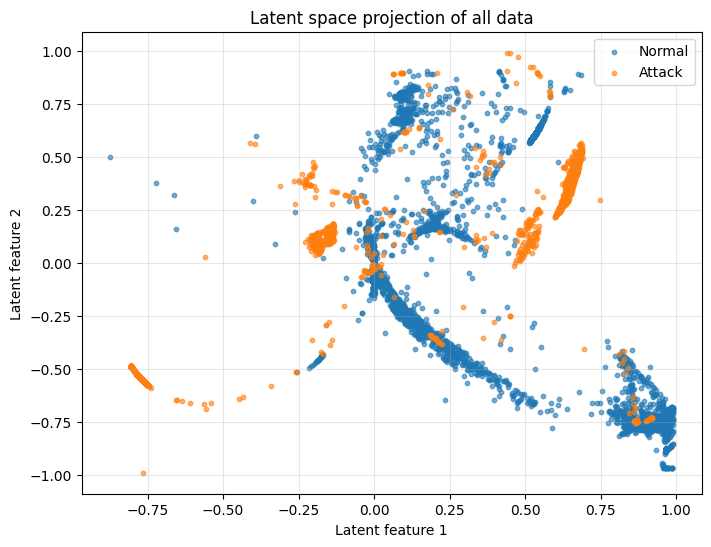

In [ ]:
Z_all = np.vstack([Z_train, Z_test])
y_all = np.concatenate([y_train_small, y_test_small])

normal = (y_all == 0)
attack = (y_all == 1)

plt.figure(figsize=(8, 6))

plt.scatter(
    Z_all[normal, 0], Z_all[normal, 1],
    s=10, alpha=0.6, label="Normal"
)
plt.scatter(
    Z_all[attack, 0], Z_all[attack, 1],
    s=10, alpha=0.6, label="Attack"
)

plt.xlabel("Latent feature 1")
plt.ylabel("Latent feature 2")
plt.title("Latent space projection of all data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
svm_clf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42,
)

svm_clf.fit(Z_train, y_train_small)

y_pred = svm_clf.predict(Z_test)
y_prob = svm_clf.predict_proba(Z_test)[:, 1]

acc = accuracy_score(y_test_small, y_pred)
cm_qae = confusion_matrix(y_test_small, y_pred)
auc = roc_auc_score(y_test_small, y_prob)
report_dict = classification_report(
    y_test_small,
    y_pred,
    target_names=["normal", "attack"],
    output_dict=True,
)

report_df = pd.DataFrame(report_dict).T

print(f"Accuracy: {acc:.4f}")
print(f"ROC-AUC:  {auc:.4f}")
display(report_df.round(4))

Accuracy: 0.9780
ROC-AUC:  0.9878


,precision,recall,f1-score,support
normal,0.9004,0.9990,0.9471,986.000
attack,0.9997,0.9728,0.9861,4014.000
accuracy,0.9780,0.9780,0.9780,0.978
macro avg,0.9501,0.9859,0.9666,5000.000
weighted avg,0.9801,0.9780,0.9784,5000.000


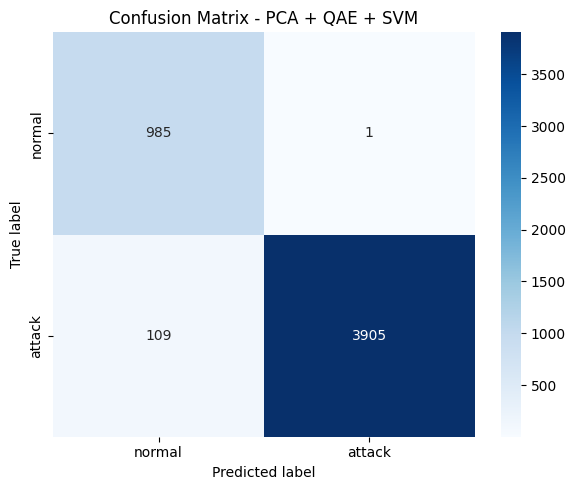

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_qae,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - PCA + QAE + SVM")
plt.tight_layout()
plt.show()

In [ ]:
svm_pca = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42,
)

svm_pca.fit(X_train_small, y_train_small)

y_pred_pca = svm_pca.predict(X_test_small)
y_prob_pca = svm_pca.predict_proba(X_test_small)[:, 1]

cm = confusion_matrix(y_test_small, y_pred_pca)

print("PCA-4 baseline")
print(f"Accuracy: {accuracy_score(y_test_small, y_pred_pca):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_small, y_prob_pca):.4f}")
print(classification_report(y_test_small, y_pred_pca))

PCA-4 baseline
Accuracy: 0.9860
ROC-AUC:  0.9914
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       986
           1       1.00      0.98      0.99      4014

    accuracy                           0.99      5000
   macro avg       0.97      0.99      0.98      5000
weighted avg       0.99      0.99      0.99      5000



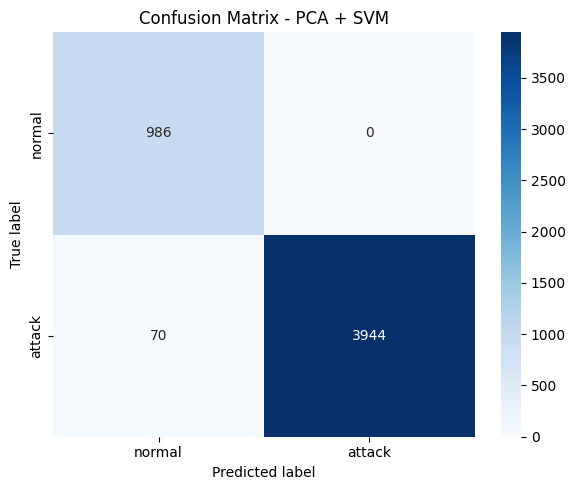

In [21]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - PCA + SVM")
plt.tight_layout()
plt.show()

Linear classifier on the first 2 principal components
Accuracy: 0.9794
ROC-AUC:  0.9944
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       986
           1       0.99      0.98      0.99      4014

    accuracy                           0.98      5000
   macro avg       0.96      0.98      0.97      5000
weighted avg       0.98      0.98      0.98      5000



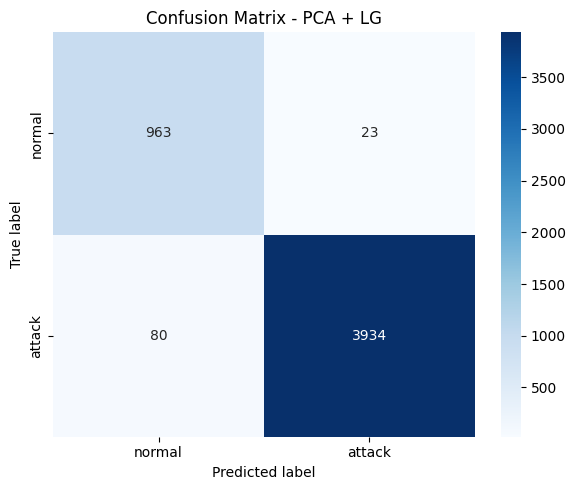

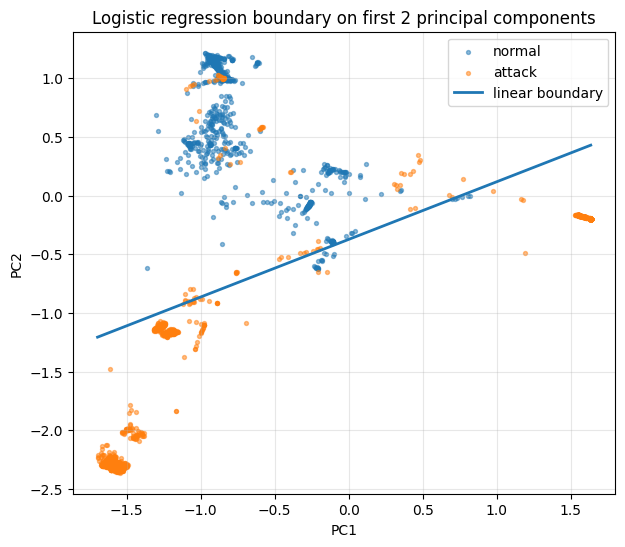

In [ ]:
X_train_pca2 = X_train_small[:, :2]
X_test_pca2 = X_test_small[:, :2]

lin_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

lin_clf.fit(X_train_pca2, y_train_small)

y_pred_pca2 = lin_clf.predict(X_test_pca2)
y_prob_pca2 = lin_clf.predict_proba(X_test_pca2)[:, 1]

print("Linear classifier on the first 2 principal components")
print(f"Accuracy: {accuracy_score(y_test_small, y_pred_pca2):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test_small, y_prob_pca2):.4f}")
print(classification_report(y_test_small, y_pred_pca2))
cm_lg = confusion_matrix(y_test_small, y_pred_pca2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - PCA + LG")
plt.tight_layout()
plt.show()

# Visualize linear boundary
plt.figure(figsize=(7, 6))

mask_normal = (y_test_small == 0)
mask_attack = (y_test_small == 1)

plt.scatter(
    X_test_pca2[mask_normal, 0],
    X_test_pca2[mask_normal, 1],
    s=8,
    alpha=0.5,
    label="normal",
)

plt.scatter(
    X_test_pca2[mask_attack, 0],
    X_test_pca2[mask_attack, 1],
    s=8,
    alpha=0.5,
    label="attack",
)

w = lin_clf.coef_[0]
b = lin_clf.intercept_[0]

x_min, x_max = X_test_pca2[:, 0].min(), X_test_pca2[:, 0].max()
xs = np.linspace(x_min, x_max, 200)

if abs(w[1]) > 1e-12:
    ys = -(w[0] * xs + b) / w[1]
    plt.plot(xs, ys, linewidth=2, label="linear boundary")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic regression boundary on first 2 principal components")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
